# Linear Regression : Salary Prediction

A complete, beginner-friendly walkthrough of Linear Regression:
theory → EDA → train/test split → training → prediction → error metrics → predicting new values.


## 1. What is Linear Regression?

**Linear Regression** is a *supervised learning* algorithm used for predicting a **continuous numeric value** based on one or more input features. It assumes there is a (roughly) **linear relationship** between the input(s) (X) and the output (y).

### Our example

- **X (Independent variable)** → Years of Experience
- **Y (Dependent variable)** → Salary

We want to find a straight line that best fits this data:

$$ y = mx + c $$

where **m = slope** (how much salary increases per year of experience), and **c = intercept** (starting salary when experience = 0).

Using regression math (or libraries like scikit-learn), the algorithm calculates:

- **Slope (m)** → average increase in salary per year of experience.
- **Intercept (c)** → base salary when experience is 0.

### Example

For example, if the regression finds:

$$ y = 9400x + 26000 $$

This means:

- Every extra year of experience adds about **₹9,400** to salary.
- Starting salary (0 years) ≈ **₹26,000**.

### Predictions

Let's predict salaries:

- **For 2 years experience:**
$$ y = 9400(2) + 26000 = 44800 $$
→ Salary ≈ **₹44,800**

- **For 10 years experience:**
$$ y = 9400(10) + 26000 = 120000 $$
→ Salary ≈ **₹1,20,000**

*(Note: these numbers are just to illustrate how the formula works. Once we train the model on our actual dataset later in this notebook, you'll see the real m and c it finds.)*


## 2. How Does Linear Regression Work?

### Step 1 : Assume a line
The model assumes the relationship between X and y can be captured by a straight line:
$$ \hat{y} = mx + c $$

### Step 2 : Define a Cost/Loss Function
We need to measure how "wrong" our line is. We use **Mean Squared Error (MSE)**:
$$ J(m, c) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

This penalizes larger errors more heavily (because of the square).

### Step 3 : Find the Best Line (Minimize the Cost)
The "best" line is the one that minimizes this cost. There are two common approaches:

1. **Ordinary Least Squares (OLS)** : a closed-form mathematical solution that directly computes the optimal $m$ and $c$ using matrix algebra. This is what `scikit-learn`'s `LinearRegression` uses by default.
2. **Gradient Descent** : an iterative approach that starts with random values for $m$ and $c$ and repeatedly nudges them in the direction that reduces the cost, using a learning rate, until it converges. This is more common for large datasets or more complex models.

### Step 4 : Use the Line to Predict
Once $m$ and $c$ are learned, we plug in a new $x$ value to get a prediction $\hat{y}$ , exactly like we did in the example above.

### Key Assumptions of Linear Regression
- **Linearity** : the relationship between X and y is linear
- **Independence** : observations are independent of each other
- **Homoscedasticity** : the variance of errors is roughly constant across all values of X
- **Normality of errors** : residuals (errors) are approximately normally distributed
- **No/low multicollinearity** : (for multiple regression) features aren't highly correlated with each other


## 3. Error Metrics for Regression

Since regression predicts continuous values, we can't use "accuracy" like in classification. Instead, we use these metrics:

| Metric | Formula | What it tells you |
|---|---|---|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Average absolute difference between actual & predicted. Easy to interpret, same unit as y. |
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Like MAE but squares errors — penalizes large mistakes more. Unit is squared (harder to interpret directly). |
| **RMSE** (Root Mean Squared Error) | $\sqrt{MSE}$ | Same unit as y, penalizes large errors. Most commonly reported metric. |
| **R² Score** (Coefficient of Determination) | $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ | Proportion of variance in y explained by the model. Ranges (typically) 0 to 1 — closer to 1 is better. |
| **Adjusted R²** | Adjusts R² for the number of features | Useful in multiple regression to avoid inflated R² from adding useless features. |

**Rule of thumb:**
- Lower **MAE / MSE / RMSE** → better model
- Higher **R²** (closer to 1) → better model
- Compare **RMSE** to the typical scale of your target variable to judge if the error is "small" or "large" in practical terms


## 4. Code Implementation

We'll use a **Salary vs Years of Experience** dataset and go through the full pipeline:

1. Import libraries
2. Load & explore the data (EDA)
3. Train/test split
4. Train the model
5. Predict on test data
6. Evaluate with error metrics
7. Predict a brand-new value from user input


### 4.1 Install Dependencies

In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 4.2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

### 4.3 Load the Dataset

We already have `salary_data.csv` (Years of Experience → Salary), so we just load it directly with pandas.

In [3]:
df = pd.read_csv("salary_data.csv")
df.head()

,YearsExperience,Salary
0,0.3,42500.0
1,0.5,42700.0
2,0.7,36100.0
3,0.7,47500.0
4,0.9,41000.0


### 4.4 Exploratory Data Analysis (EDA)

Before modeling, we always want to understand the data:
- Shape & data types
- Missing values
- Summary statistics
- Distribution & relationship between features


In [4]:
# Basic info
print("Shape:", df.shape)
df.info()

Shape: (60, 2)
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  60 non-null     float64
 1   Salary           60 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


In [5]:
# Check for missing values
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [6]:
# Summary statistics
df.describe()

,YearsExperience,Salary
count,60.000000,60.000000
mean,7.013333,66040.000000
std,4.575634,20613.137164
min,0.300000,32400.000000
25%,2.800000,48725.000000
50%,6.700000,63450.000000
75%,10.700000,82000.000000
max,14.500000,105800.000000


In [7]:
# Correlation between feature and target
df.corr(numeric_only=True)

,YearsExperience,Salary
YearsExperience,1.000000,0.966009
Salary,0.966009,1.000000


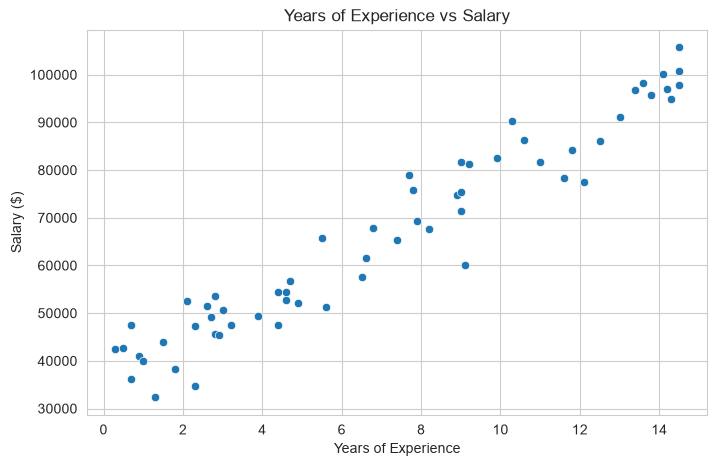

In [8]:
# Visualize the relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="YearsExperience", y="Salary")
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary ($)")
plt.show()

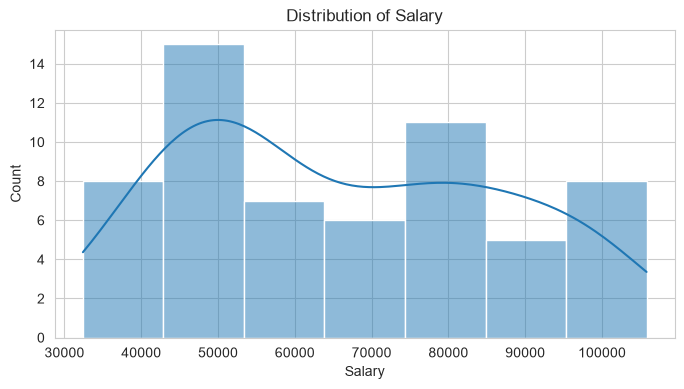

In [9]:
# Distribution of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df["Salary"], kde=True)
plt.title("Distribution of Salary")
plt.show()

### 4.5 Train/Test Split

We split the data so we can train on one portion and evaluate on unseen data — this tells us how well the model generalizes.

In [10]:
X = df[["YearsExperience"]]   # Features (must be 2D)
y = df["Salary"]              # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 48
Testing samples: 12


### 4.6 Manual Calculation of y = mx + c (Least Squares by Hand)

Before letting `scikit-learn` do the work, let's calculate the slope ($m$) and intercept ($c$) ourselves using the **Ordinary Least Squares** formulas, so you can see exactly where the line comes from:

$$ m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} $$

$$ c = \bar{y} - m \bar{x} $$

Where $\bar{x}$ and $\bar{y}$ are the means of X and y in the **training set**.

In [11]:
# Flatten X_train to a 1D array for manual calculation
x_vals = X_train["YearsExperience"].values
y_vals = y_train.values

x_mean = np.mean(x_vals)
y_mean = np.mean(y_vals)

numerator = np.sum((x_vals - x_mean) * (y_vals - y_mean))
denominator = np.sum((x_vals - x_mean) ** 2)

m = numerator / denominator          # slope
c = y_mean - m * x_mean              # intercept

print(f"Manually calculated slope (m): {m:.2f}")
print(f"Manually calculated intercept (c): {c:.2f}")
print(f"\nEquation: y = {m:.2f}x + {c:.2f}")
print(f"i.e.      Salary = {m:.2f} * YearsExperience + {c:.2f}")

Manually calculated slope (m): 4443.64
Manually calculated intercept (c): 34716.76

Equation: y = 4443.64x + 34716.76
i.e.      Salary = 4443.64 * YearsExperience + 34716.76


### 4.7 Train the Linear Regression Model (scikit-learn)

Now let's fit the same model using `scikit-learn` and confirm it lands on the same $m$ and $c$ we just calculated by hand.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"sklearn Intercept (c): {model.intercept_:.2f}")

sklearn Intercept (c): 34716.76


In [13]:
print(f"sklearn Coefficient/slope (m): {model.coef_[0]:.2f}")

sklearn Coefficient/slope (m): 4443.64


In [14]:
print(f"\nEquation: Salary = {model.coef_[0]:.2f} * YearsExperience + {model.intercept_:.2f}")


Equation: Salary = 4443.64 * YearsExperience + 34716.76


In [15]:
print(f"\nMatches manual calculation? m: {np.isclose(m, model.coef_[0])}, c: {np.isclose(c, model.intercept_)}")


Matches manual calculation? m: True, c: True


### 4.8 Predict on the Test Set

In [16]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred, 2),
    "Difference": np.round(y_test.values - y_pred, 2)
})
results

,Actual,Predicted,Difference
0,42500.0,36049.85,6450.15
1,40000.0,39160.39,839.61
2,74800.0,74265.11,534.89
3,81700.0,83596.74,-1896.74
4,49100.0,46714.57,2385.43
5,100200.0,97372.01,2827.99
6,75900.0,69377.11,6522.89
7,77500.0,88484.74,-10984.74
8,51600.0,46270.21,5329.79
9,105800.0,99149.47,6650.53


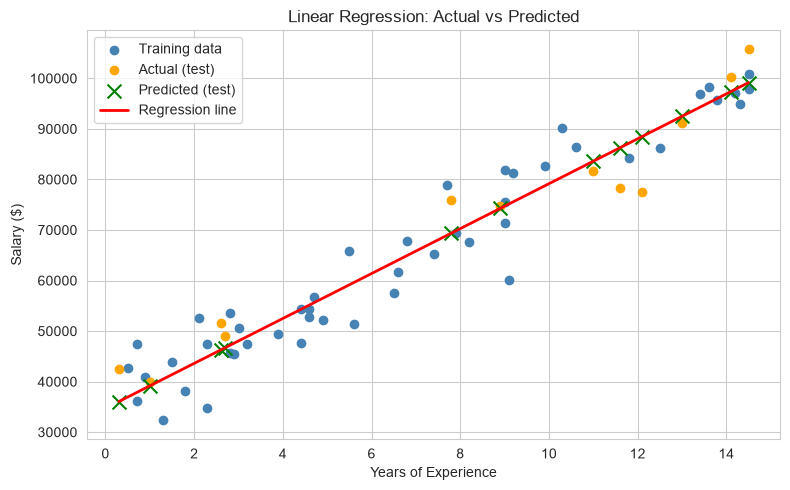

In [17]:
# Visualize predictions vs actual
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="steelblue", label="Training data")
plt.scatter(X_test, y_test, color="orange", label="Actual (test)")
plt.scatter(X_test, y_pred, color="green", marker="x", s=100, label="Predicted (test)")

x_line = np.linspace(X["YearsExperience"].min(), X["YearsExperience"].max(), 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=["YearsExperience"])
plt.plot(x_line_df, model.predict(x_line_df), color="red", linewidth=2, label="Regression line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary ($)")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

### 4.9 Error Metrics — Evaluate Model Performance

We calculate MAE, MSE, RMSE, and R² (as explained in Section 3) to judge how good the model is.

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

print(f"\nInterpretation: On average, predictions are off by about ${rmse:,.0f}, "
      f"and the model explains {r2*100:.1f}% of the variance in Salary.")

MAE  : 4464.14
MSE  : 29933674.71
RMSE : 5471.17
R2   : 0.9326

Interpretation: On average, predictions are off by about $5,471, and the model explains 93.3% of the variance in Salary.


### 4.10 Residual Plot (Bonus Diagnostic)

Residuals (errors) should be randomly scattered around zero with no obvious pattern — this supports the linearity & homoscedasticity assumptions.

In [ ]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

### 4.11 Predict a New Value from User Input

Now let's use the trained model to predict salary for a brand-new years-of-experience value.

In [ ]:
def predict_salary(years_experience: float) -> float:
    """Predict salary for a given years of experience using the trained model."""
    input_df = pd.DataFrame({"YearsExperience": [years_experience]})
    predicted_salary = model.predict(input_df)[0]
    return predicted_salary

# --- Try it out ---
# Replace the value below, or use input() to type it interactively when running the notebook.
new_experience = 7.5   # <-- change this value, or use: float(input("Enter years of experience: "))

predicted = predict_salary(new_experience)
print(f"Predicted salary for {new_experience} years of experience: ${predicted:,.2f}")

In [ ]:
# Optional: interactive version (uncomment to use when running the notebook live)
# years_input = float(input("Enter years of experience: "))
# predicted = predict_salary(years_input)
# print(f"Predicted salary: ${predicted:,.2f}")

## 5. Summary

- Linear Regression fits a straight line ($y = \beta_0 + \beta_1 x$) that best represents the relationship between input and output by minimizing **Mean Squared Error**.
- We evaluated the model using **MAE, MSE, RMSE, and R²** — RMSE tells us the typical prediction error in the same units as the target, and R² tells us how much variance is explained.
- The trained model can now predict salary for **any new years-of-experience value** by plugging it into the learned equation.

### Next steps to explore
- Try **Multiple Linear Regression** by adding more features (e.g., education level, job role, location)
- Check assumptions more formally (e.g., Q-Q plot for residual normality, Variance Inflation Factor for multicollinearity)
- Try **Polynomial Regression** if the relationship isn't perfectly linear
- Use **cross-validation** instead of a single train/test split for a more robust performance estimate
